In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Load the saved CSV files
train_df = pd.read_csv('/content/drive/MyDrive/COMM074_Project_Personal/preprocessed/train_preprocessed.csv')
test_df = pd.read_csv('/content/drive/MyDrive/COMM074_Project_Personal/preprocessed/test_preprocessed.csv')

# Separate features (X) and target (y) for training
X_train_loaded = train_df.drop(columns=['target'])
y_train_loaded = train_df['target']

# Separate features (X) and target (y) for testing
X_test_loaded = test_df.drop(columns=['target'])
y_test_loaded = test_df['target']

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, balanced_accuracy_score, accuracy_score,
    roc_auc_score, roc_curve, auc
)

**Decision Tree**

In [4]:
def evaluate_dt(classifier, cv, param):  # defining function for performing grid search cross validation
  grid_search_dt = GridSearchCV(
      classifier,
      param,
      cv=cv,
      scoring='f1_macro',
  )
  grid_search_dt.fit(X_train_loaded, y_train_loaded)

  print("\n--- DECISION TREE TUNING RESULTS ---")
  return grid_search_dt

In [5]:
dt_model = DecisionTreeClassifier(random_state=42)

kfold = StratifiedKFold(n_splits=5, shuffle=True)

# defining parameter range
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 15, 25, 50],
    'min_samples_split': [2, 5, 10, 2],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': ['balanced']
}

# calling the evaluate_dt function
grid_search_dt = evaluate_dt(classifier=dt_model, cv=kfold, param=param_grid_dt)

print("\n--- DECISION TREE TUNING RESULTS ---")
print(f"Best Hyperparameters: {grid_search_dt.best_params_}")
print(f"Best Cross-Validation f1_macro: {grid_search_dt.best_score_:.4f}")



--- DECISION TREE TUNING RESULTS ---

--- DECISION TREE TUNING RESULTS ---
Best Hyperparameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best Cross-Validation f1_macro: 0.5160


**Evaluating Performance on Test Set**

In [6]:
from sklearn.metrics import classification_report
best_dt = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=10, min_samples_split=2, random_state=42)
best_dt.fit(X_train_loaded, y_train_loaded)
y_pred_dt = best_dt.predict(X_test_loaded)
dt_report = classification_report(y_test_loaded, y_pred_dt, output_dict=True)
df_report = pd.DataFrame(dt_report).T

display(df_report)

,precision,recall,f1-score,support
0,0.555556,0.616197,0.584307,284.00000
1,0.370370,0.062893,0.107527,159.00000
2,0.642726,0.789593,0.708629,442.00000
accuracy,0.603390,0.603390,0.603390,0.60339
macro avg,0.522884,0.489561,0.466821,885.00000
weighted avg,0.565821,0.603390,0.560739,885.00000


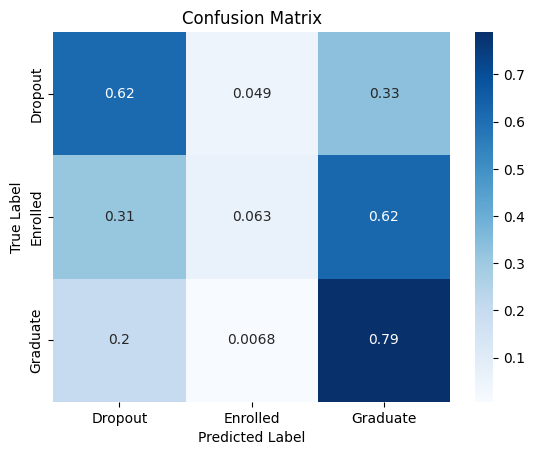

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_labels = ['Dropout', 'Enrolled', 'Graduate']

fig, ax = plt.subplots()

sns.heatmap(
    confusion_matrix(y_test_loaded, y_pred_dt, normalize='true'),
    annot=True,
    cmap='Blues',
    ax=ax,
    xticklabels=class_labels,
    yticklabels=class_labels
)

ax.set_title('Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.show()

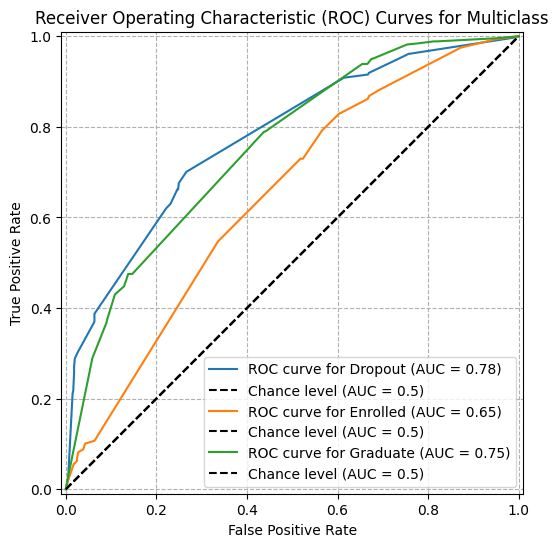

In [8]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

y_score = best_dt.predict_proba(X_test_loaded)
fig, ax = plt.subplots(figsize=(8, 6))

class_labels = ['Dropout', 'Enrolled', 'Graduate']

for i, class_name in enumerate(class_labels):
    y_true_binary = (y_test_loaded == i)
    y_score_class = y_score[:, i]

    RocCurveDisplay.from_predictions(
        y_true_binary,
        y_score_class,
        name=f"ROC curve for {class_name}",
        ax=ax,
        plot_chance_level=True,
    )

ax.set_title("Receiver Operating Characteristic (ROC) Curves for Multiclass")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc='lower right')
plt.grid(linestyle='--')
plt.show()

dt_auc = roc_auc_score(y_true_binary, y_score_class, multi_class='ovr', average='macro')

**Feature Importance**

<Axes: >

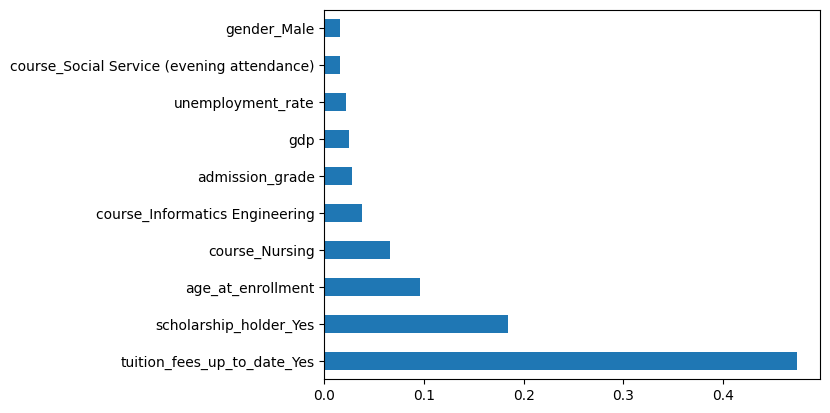

In [9]:
feature_importances = pd.Series(best_dt.feature_importances_, index=X_train_loaded.columns)
feature_importances.nlargest(10).plot(kind='barh')

**Plotting the Tree**

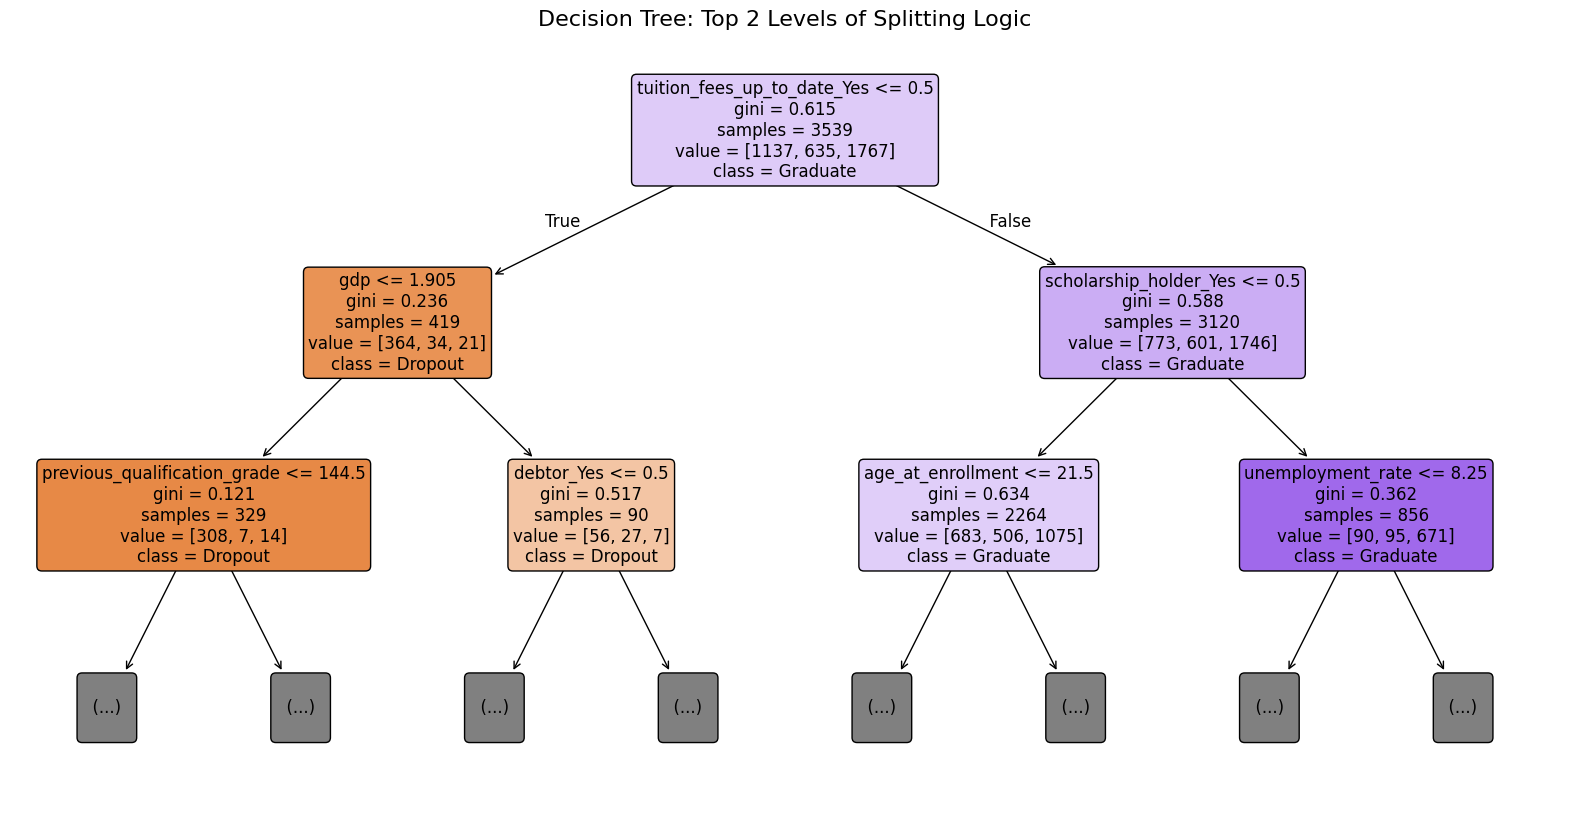

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(best_dt,
          feature_names=X_train_loaded.columns,
          class_names=['Dropout', 'Enrolled', 'Graduate'],
          filled=True,
          rounded=True,
          max_depth=2,
          fontsize=12)

plt.title("Decision Tree: Top 2 Levels of Splitting Logic", fontsize=16)
plt.show()

**Logistic Regression (Common Baseline)**

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

In [12]:
def evaluate(classifier, cv, param):  # defining function for performing grid search
  print("\nTuning Logistic Regression (with Class Weights)...")
  grid_search_lr = GridSearchCV(classifier, param, cv=cv, scoring='f1_macro')

  grid_search_lr.fit(X_train_loaded, y_train_loaded)
  return grid_search_lr

In [13]:

lr_balanced = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)

kfold = StratifiedKFold(n_splits=5, shuffle=True)

# defining the hyperparameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'max_iter': [1000, 1500],
}


clf = evaluate(classifier=lr_balanced, cv=kfold, param=param_grid_lr) # calling evaluate function to tune hyperparameters
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Best Cross-Validation Score (Macro F1): {clf.best_score_:.4f}")


Tuning Logistic Regression (with Class Weights)...
Best Hyperparameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l1'}
Best Cross-Validation Score (Macro F1): 0.5826


**Evaluating on Test Set**

In [14]:
from sklearn.metrics import classification_report
best_lr = LogisticRegression(class_weight='balanced',solver='liblinear', C=1, max_iter=1000, penalty='l2', random_state=42)
best_lr.fit(X_train_loaded, y_train_loaded)
y_pred_lr = best_lr.predict(X_test_loaded)
lr_report = classification_report(y_test_loaded, y_pred_lr, output_dict=True)
df_report = pd.DataFrame(lr_report).T

display(df_report)

,precision,recall,f1-score,support
0,0.670782,0.573944,0.618596,284.000000
1,0.320000,0.352201,0.335329,159.000000
2,0.695931,0.735294,0.715072,442.000000
accuracy,0.614689,0.614689,0.614689,0.614689
macro avg,0.562238,0.553813,0.556332,885.000000
weighted avg,0.620321,0.614689,0.615887,885.000000


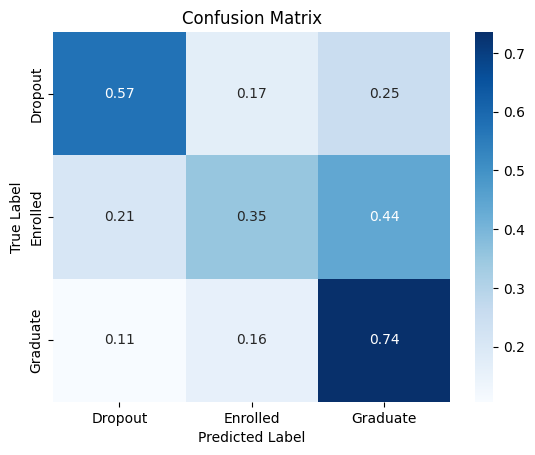

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_labels = ['Dropout', 'Enrolled', 'Graduate']

fig, ax = plt.subplots()

sns.heatmap(
    confusion_matrix(y_test_loaded, y_pred_lr, normalize='true'),
    annot=True,
    cmap='Blues',
    ax=ax,
    xticklabels=class_labels,
    yticklabels=class_labels
)

ax.set_title('Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.show()

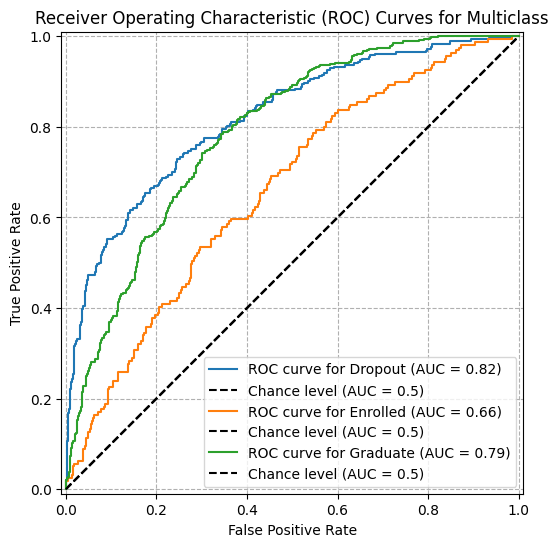

In [16]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

y_score = best_lr.predict_proba(X_test_loaded)
fig, ax = plt.subplots(figsize=(8, 6))

class_labels = ['Dropout', 'Enrolled', 'Graduate']

for i, class_name in enumerate(class_labels):
    y_true_binary = (y_test_loaded == i)
    y_score_class = y_score[:, i]

    RocCurveDisplay.from_predictions(
        y_true_binary,
        y_score_class,
        name=f"ROC curve for {class_name}",
        ax=ax,
        plot_chance_level=True,
    )

ax.set_title("Receiver Operating Characteristic (ROC) Curves for Multiclass")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc='lower right')
plt.grid(linestyle='--')
plt.show()

lr_auc = roc_auc_score(y_true_binary, y_score_class, multi_class='ovr', average='macro')

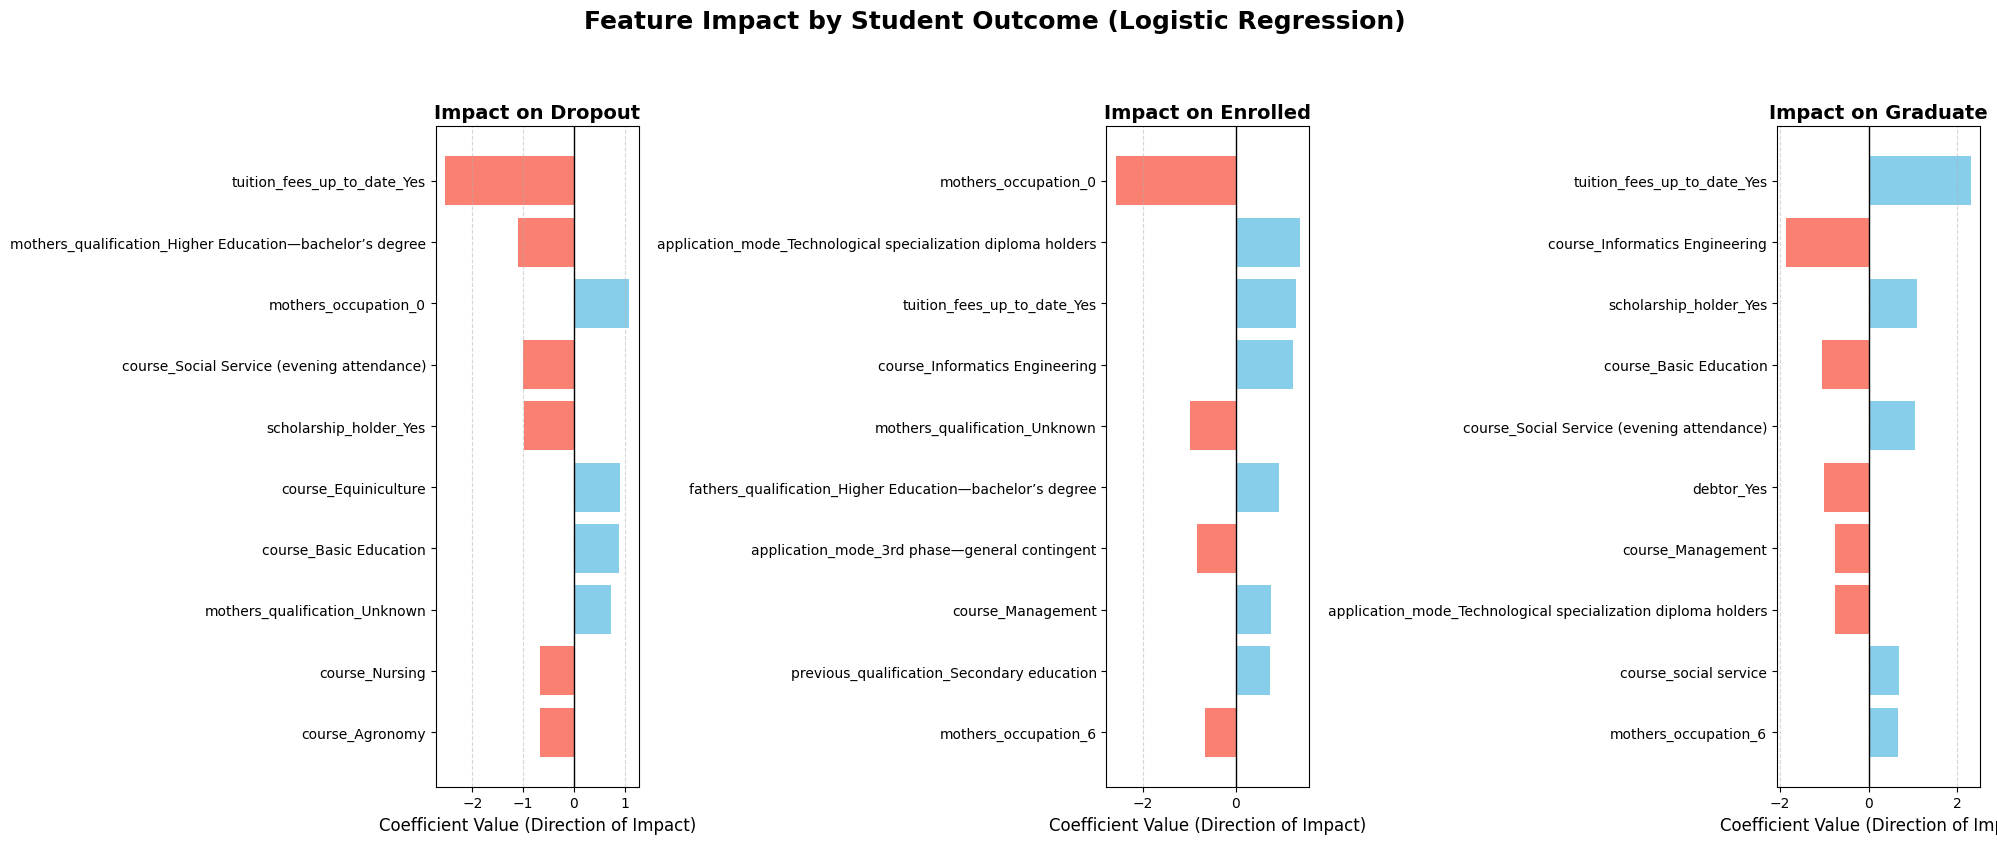

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

N_TOP_FEATURES = 10
class_names = ['Dropout', 'Enrolled', 'Graduate']

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharex=False)
fig.suptitle('Feature Impact by Student Outcome (Logistic Regression)', fontsize=18, fontweight='bold', y=1.05)

for i, class_label in enumerate(class_names):

    coef_df = pd.DataFrame({
        'Feature': X_train_loaded.columns,
        'Coefficient': best_lr.coef_[i]
    })

    coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

    top_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(N_TOP_FEATURES)

    top_features = top_features.iloc[::-1]

    colors = ['skyblue' if c >= 0 else 'salmon' for c in top_features['Coefficient']]

    axes[i].barh(top_features['Feature'], top_features['Coefficient'], color=colors)
    axes[i].axvline(0, color='black', linestyle='-', linewidth=1) # Center line

    axes[i].set_xlabel('Coefficient Value (Direction of Impact)', fontsize=12)
    axes[i].set_title(f'Impact on {class_label}', fontsize=14, fontweight='bold')
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Combined Classification Report Results**

In [18]:
from sklearn.metrics import classification_report
import pandas as pd

# Classification report for decision tree
df_dt = pd.DataFrame(dt_report).T
df_dt.index.name = 'Class'
df_dt = df_dt.reset_index()
df_dt = df_dt.set_index('Class')

# classification report for logistic regression
df_lr = pd.DataFrame(lr_report).T
df_lr.index.name = 'Class'
df_lr = df_lr.reset_index()
df_lr = df_lr.set_index('Class')

combined_report = pd.concat([df_dt, df_lr], axis=1)

new_column_names = [
    'DT_Precision', 'DT_Recall', 'DT_F1-Score', 'DT_Support',
    'LR_Precision', 'LR_Recall', 'LR_F1-Score', 'LR_Support'
]
combined_report.columns = new_column_names

combined_report = combined_report.reset_index()
combined_report

,Class,DT_Precision,DT_Recall,DT_F1-Score,DT_Support,LR_Precision,LR_Recall,LR_F1-Score,LR_Support
0,0,0.555556,0.616197,0.584307,284.00000,0.670782,0.573944,0.618596,284.000000
1,1,0.370370,0.062893,0.107527,159.00000,0.320000,0.352201,0.335329,159.000000
2,2,0.642726,0.789593,0.708629,442.00000,0.695931,0.735294,0.715072,442.000000
3,accuracy,0.603390,0.603390,0.603390,0.60339,0.614689,0.614689,0.614689,0.614689
4,macro avg,0.522884,0.489561,0.466821,885.00000,0.562238,0.553813,0.556332,885.000000
5,weighted avg,0.565821,0.603390,0.560739,885.00000,0.620321,0.614689,0.615887,885.000000


**Visualizing Per-Class Metrics for both models**

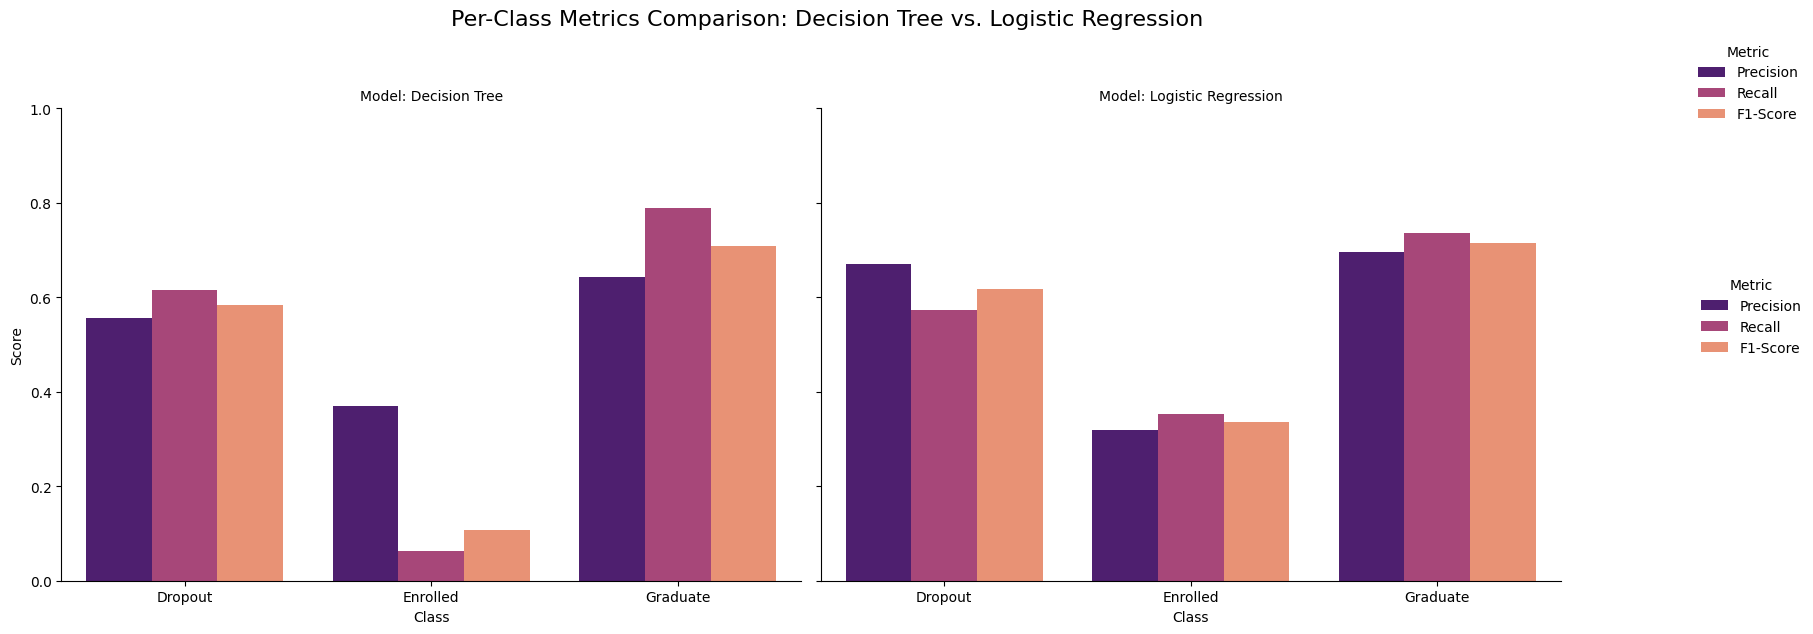

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

class_metrics_df = combined_report[combined_report['Class'].isin(['0', '1', '2'])].copy()

class_metrics_df['Class'] = class_metrics_df['Class'].astype(int)
class_metrics_df = class_metrics_df.sort_values(by='Class').set_index('Class')

class_names = ['Dropout', 'Enrolled', 'Graduate']

metrics_to_plot = ['Precision', 'Recall', 'F1-Score']

data_for_plot = []
for class_idx in class_metrics_df.index:
    for metric in metrics_to_plot:
        dt_value = class_metrics_df.loc[class_idx, f'DT_{metric}']
        lr_value = class_metrics_df.loc[class_idx, f'LR_{metric}']
        data_for_plot.append({
            'Class': class_names[class_idx],
            'Metric': metric,
            'Model': 'Decision Tree',
            'Value': dt_value
        })
        data_for_plot.append({
            'Class': class_names[class_idx],
            'Metric': metric,
            'Model': 'Logistic Regression',
            'Value': lr_value
        })

plot_df = pd.DataFrame(data_for_plot)


g = sns.catplot(
    x='Class',
    y='Value',
    hue='Metric',
    col='Model',
    data=plot_df,
    kind='bar',
    palette='magma',
    height=6,
    aspect=1.2
)

g.set_axis_labels("Class", "Score")
g.set_titles("Model: {col_name}")

g.set(ylim=(0, 1))

g.add_legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.suptitle('Per-Class Metrics Comparison: Decision Tree vs. Logistic Regression', fontsize=16, y=1.05)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

Observing the above results, it can be concluded that Logistic Regression outperforms Decision Tree.

In [20]:
import os

PROJECT_DIR = '/content/drive/MyDrive/COMM074_Project'
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

my_results = pd.DataFrame([
    {
        'member': 'Mahi',
        'model': 'Decision Tree',
        'model_type': 'unique',
        'best_params': str(grid_search_dt.best_params_),
        'accuracy': accuracy_score(y_test_loaded, y_pred_dt),
        'balanced_accuracy': balanced_accuracy_score(y_test_loaded, y_pred_dt),
        'macro_f1': f1_score(y_test_loaded, y_pred_dt, average='macro'),
        'weighted_f1': f1_score(y_test_loaded, y_pred_dt, average='weighted'),
        'roc_auc': dt_auc,
        'dropout_f1': f1_score(y_test_loaded, y_pred_dt, average=None)[0],
        'enrolled_f1': f1_score(y_test_loaded, y_pred_dt, average=None)[1],
        'graduate_f1': f1_score(y_test_loaded, y_pred_dt, average=None)[2],
    },
    {
        'member': 'Mahi',
        'model': 'Logistic Regression',
        'model_type': 'shared',
        'best_params': str(clf.best_params_),
        'accuracy': accuracy_score(y_test_loaded, y_pred_lr),
        'balanced_accuracy': balanced_accuracy_score(y_test_loaded, y_pred_lr),
        'macro_f1': f1_score(y_test_loaded, y_pred_lr, average='macro'),
        'weighted_f1': f1_score(y_test_loaded, y_pred_lr, average='weighted'),
        'roc_auc': lr_auc,
        'dropout_f1': f1_score(y_test_loaded, y_pred_lr, average=None)[0],
        'enrolled_f1': f1_score(y_test_loaded, y_pred_lr, average=None)[1],
        'graduate_f1': f1_score(y_test_loaded, y_pred_lr, average=None)[2],
    },
])

results_path = os.path.join(RESULTS_DIR, 'results_mahi.csv')
my_results.to_csv(results_path, index=False)

print(f'Saved to: {results_path}')
print(my_results[['member', 'model', 'balanced_accuracy', 'macro_f1', 'roc_auc']].to_string(index=False))

Saved to: /content/drive/MyDrive/COMM074_Project/results/results_mahi.csv
member               model  balanced_accuracy  macro_f1  roc_auc
  Mahi       Decision Tree           0.489561  0.466821 0.754221
  Mahi Logistic Regression           0.553813  0.556332 0.786753
